# 01 — Data Exploration
Verify Mall dataset structure and display sample frames.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import scipy.io

## Dataset structure

In [11]:
RAW = Path('../data/raw')

frames = sorted(RAW.glob('frames/seq_*.jpg'))

print(f'mall_gt.mat      present: {(RAW / "mall_gt.mat").exists()}')
print(f'perspective_roi.mat present: {(RAW / "perspective_roi.mat").exists()}')
print(f'frames           count: {len(frames)}')
print(f'first frame      {frames[0].name}')
print(f'last frame       {frames[-1].name}')

mall_gt.mat      present: True
perspective_roi.mat present: True
frames           count: 2000
first frame      seq_000001.jpg
last frame       seq_002000.jpg


## Sample frames

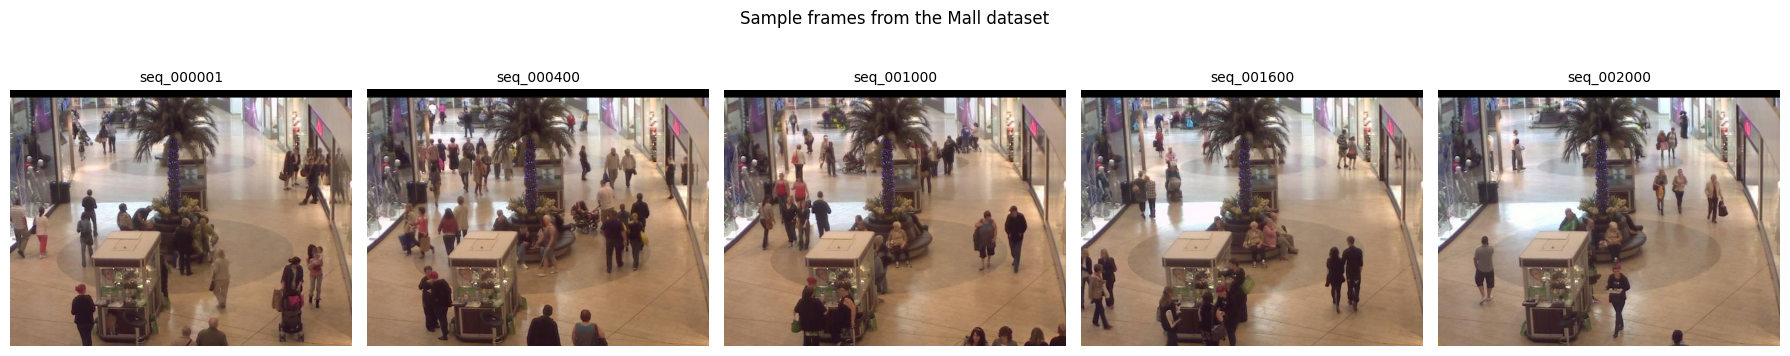

In [21]:
sample_indices = [0, 399, 999, 1599, 1999]
sample_frames = [frames[i] for i in sample_indices]

fig, axes = plt.subplots(1, len(sample_frames), figsize=(18, 4))
for ax, path in zip(axes, sample_frames):
    ax.imshow(mpimg.imread(path))
    ax.set_title(path.stem, fontsize=10)
    ax.axis('off')

plt.suptitle('Sample frames from the Mall dataset')
plt.tight_layout()
plt.show()

## Annotation format

In [39]:
gt = scipy.io.loadmat(RAW / 'mall_gt.mat')

counts = gt['count'].flatten()  # shape (2000,)

# frame[0, i][0, 0][0] → Nx2 float array of (x, y) head positions
heads_frame0 = gt['frame'][0, 0][0, 0][0]

print(f'count shape: {counts.shape}, dtype: {counts.dtype}')
print(f'frame 1: {len(heads_frame0)} people detected (gt count={counts[0]})')
print('first 5 head positions (x, y):')
print(heads_frame0[:5].round(1))

count shape: (2000,), dtype: uint8
frame 1: 29 people detected (gt count=29)
first 5 head positions (x, y):
[[126.8  60.7]
 [117.   47.6]
 [175.1  44.3]
 [184.1  45.1]
 [192.3  44.3]]


## Pedestrian counts over time

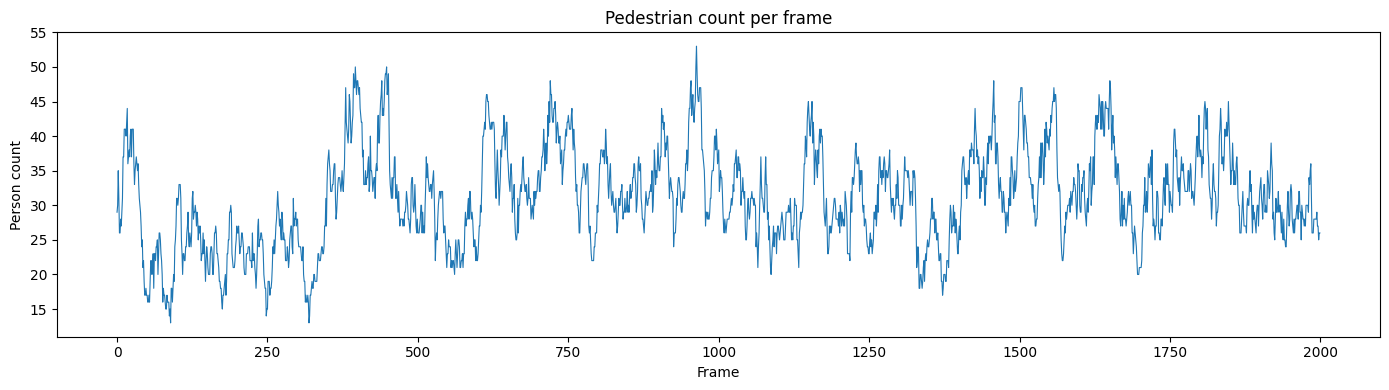

In [41]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(counts, linewidth=0.8)
ax.set_xlabel('Frame')
ax.set_ylabel('Person count')
ax.set_title('Pedestrian count per frame')
plt.tight_layout()
plt.show()